In [90]:
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import shap 
from dataclasses import dataclass
from sklearn.dummy import DummyClassifier   
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, brier_score_loss
)

In [91]:
@dataclass
class Config:
    test_size: float = 0.2
    val_size: float = 0.2
    n_iter_search: int = 20
    cv_folds: int = 5
    random_state: int = 42

In [92]:
csv_path = os.path.join(os.getcwd(), 'DataSet', 'heart_cleaned.csv')

df = pd.read_csv(csv_path)

df_atualizado = df.copy()




In [93]:
X = df_atualizado.drop('HeartDisease', axis=1)

y = df_atualizado['HeartDisease']

print("Balanceamento:\n", y.value_counts())

colunas_numericas = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
colunas_categoricas = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']




Balanceamento:
 HeartDisease
1    508
0    410
Name: count, dtype: int64


In [94]:
def split_data(X, y, config):
    # 1. separa treino e teste
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=config.test_size,
        stratify=y,
        random_state=42
    )

    # 2. separa treino e validação
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=config.val_size,
        stratify=y_train_full,
        random_state=42
    )
    

    return X_train, X_val, X_test, y_train, y_val, y_test




In [95]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, config=Config())

print("Tamanho do treino:", len(X_train))
print("Tamanho da validação:", len(X_val))
print("Tamanho do teste:", len(X_test))
   

Tamanho do treino: 587
Tamanho da validação: 147
Tamanho do teste: 184


In [96]:
config = Config()

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, config)

dummy = DummyClassifier(strategy="most_frequent")  
dummy.fit(X_train, y_train)  
  
y_probs = dummy.predict_proba(X_val)[:, 1]  
score = average_precision_score(y_val, y_probs)  
  
print("Baseline PR AUC:", score)

Baseline PR AUC: 0.5510204081632653


In [97]:
def build_pipeline(numerical_cols, categorical_cols):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ])

    model = RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    return pipeline

In [98]:
def tune_model(pipeline, X_train, y_train, config):  
  
    param_dist = {  
    "model__n_estimators": [100, 200, 300],  
    "model__max_depth": [None, 5, 10, 20],  
    "model__min_samples_split": [2, 5, 10],  
    }  
    
    search = RandomizedSearchCV(  
    pipeline,  
    param_distributions=param_dist,  
    n_iter=config.n_iter_search,  
    scoring="average_precision",  
    cv=config.cv_folds,  
    n_jobs=1,  
    random_state=42,  
    )  
    
    search.fit(X_train, y_train)  
    
    return search.best_estimator_




In [99]:

best_pipeline = tune_model(
    build_pipeline(colunas_numericas, colunas_categoricas),
    X_train, y_train, config
)
print("Melhores parâmetros:", best_pipeline.get_params())

Melhores parâmetros: {'memory': None, 'steps': [('preprocessor', ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'RestingBP', 'Cholesterol',
                                  'FastingBS', 'MaxHR', 'Oldpeak']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Sex', 'ChestPainType', 'RestingECG',
                                  'ExerciseAngina', 'ST_Slope'])])), ('model', RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=10, n_estimators=300, random_state=42))], 'transform_input': None, 'verbose': False, 'preprocessor': ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'RestingBP', 'Cholesterol',
                                  'FastingBS', 'MaxHR', 'Oldpeak']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                            

In [100]:
 
#  calibrar usando validação  
calibrated = CalibratedClassifierCV(  
best_pipeline,  
method="sigmoid", # mais seguro  
cv=None  
)  
calibrated.fit(X_val, y_val)



,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=42))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the co

In [101]:
def choose_best_model(original_model, calibrated_model, X_val, y_val):  
  
	# probabilidades  
	y_prob_orig = original_model.predict_proba(X_val)[:, 1]  
	y_prob_cal = calibrated_model.predict_proba(X_val)[:, 1]  
	  
	# 2. Métrica principal (PR AUC)  
	ap_orig = average_precision_score(y_val, y_prob_orig)  
	ap_cal = average_precision_score(y_val, y_prob_cal)  
	 
	# 3. Métrica complementar (ROC AUC) 
	roc_orig = roc_auc_score(y_val, y_prob_orig)  
	roc_cal = roc_auc_score(y_val, y_prob_cal)  
	
	# 4. Mostrar comparação  
	print("=== Comparação ===")  
	print(f"Original → PR AUC: {ap_orig:.4f} | ROC AUC: {roc_orig:.4f}")  
	print(f"Calibrado → PR AUC: {ap_cal:.4f} | ROC AUC: {roc_cal:.4f}")  
	  
	# 5. Escolha baseada em PR AUC  
	if ap_cal > ap_orig:  
		best_model = calibrated_model  
		print("\n✔️ Escolha: MODELO CALIBRADO (melhor PR AUC)")  
	else:  
		best_model = original_model  
		print("\n✔️ Escolha: MODELO ORIGINAL (melhor PR AUC)")  
	  
	# 6. Interpretação com ROC (insight extra)  
	best_roc = roc_cal if best_model == calibrated_model else roc_orig  
	  
	if best_roc < 0.6:  
		print("⚠️ Atenção: baixa separação entre classes (modelo pode estar confuso)")  
	elif best_roc > 0.85:  
		print("✅ Boa separação entre classes")  
	else:  
		print("ℹ️ Separação moderada entre classes")  
	  
	return best_model

best_model = choose_best_model(best_pipeline, calibrated, X_val, y_val)

=== Comparação ===
Original → PR AUC: 0.8896 | ROC AUC: 0.9102
Calibrado → PR AUC: 0.9805 | ROC AUC: 0.9762

✔️ Escolha: MODELO CALIBRADO (melhor PR AUC)
✅ Boa separação entre classes


In [102]:
def find_best_threshold(best_model, X, y_true, target_sensitivity=0.95):
    y_proba = best_model.predict_proba(X)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 181)
    candidates = []
    recalls = []
    precisions = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
        specificity = tn / (tn + fp) if (tn + fp) else 0.0
        recalls.append(sensitivity)
        precisions.append(specificity)

        if sensitivity >= target_sensitivity:
            candidates.append({"threshold": t, "specificity": specificity})
            
    
    best_t = max(candidates, key=lambda d: d["specificity"])["threshold"]

    return best_t, thresholds, recalls, precisions

	# Passa X_val — não X_test
best_t = find_best_threshold(best_model, X_val, y_val)



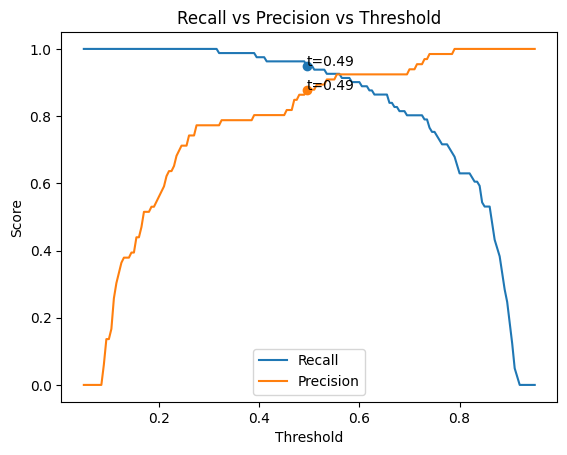

In [103]:
best_t, thresholds, recalls, precisions = find_best_threshold(best_model, X_val, y_val)

idx = (np.abs(thresholds - best_t)).argmin()  
  
plt.figure()  
plt.plot(thresholds, recalls, label="Recall")  
plt.plot(thresholds, precisions, label="Precision")  
  
plt.scatter(thresholds[idx], recalls[idx])  
plt.scatter(thresholds[idx], precisions[idx])  
  
plt.text(thresholds[idx], recalls[idx], f"t={best_t:.2f}")  
plt.text(thresholds[idx], precisions[idx], f"t={best_t:.2f}")  
  
plt.xlabel("Threshold")  
plt.ylabel("Score")  
plt.title("Recall vs Precision vs Threshold")  
plt.legend()  
plt.show()


In [104]:
y_proba_test = best_model.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= best_t).astype(int)

print(classification_report(y_test, y_pred_test))
print(confusion_matrix(y_test, y_pred_test))



              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

[[71 11]
 [ 9 93]]


In [105]:
if hasattr(best_model, "calibrated_classifiers_"):
    pipeline = best_model.calibrated_classifiers_[0].estimator
else:
    pipeline = best_model

preprocess = pipeline.named_steps["preprocessor"]
model = pipeline.named_steps["model"]


#Transformar dados
X_train_transformed = preprocess.transform(X_train)  
X_val_transformed = preprocess.transform(X_val)

#Nome das features (CRÍTICO)
feature_names = (  
	colunas_numericas +  
	list(  
		preprocess  
		.named_transformers_["cat"]  
		.get_feature_names_out(colunas_categoricas)  
	)  
)

#Criar explainer (automático)
explainer = shap.Explainer(model, X_train_transformed, feature_names=feature_names)
shap_values = explainer(X_val_transformed, check_additivity=False)

#Gráfico GLOBAL (importância real)
os.makedirs("img", exist_ok=True)

plt.figure()
shap.plots.bar(shap_values[:, :, 1], show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig("img/shap_global.png")
plt.close()

#Summary plot (distribuição + impacto)
plt.figure()
shap.summary_plot(
    shap_values,
    X_val_transformed,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.savefig("img/shap_summary.png")
plt.close()

#8. Explicação INDIVIDUAL (1 paciente)
idx = 0 #   trocar depois  para o paciente que desejar
  
plt.figure()  
shap.plots.waterfall(shap_values[idx, :, 1], show=False)  
plt.tight_layout()  
plt.savefig("img/shap_individual.png")  
plt.close()

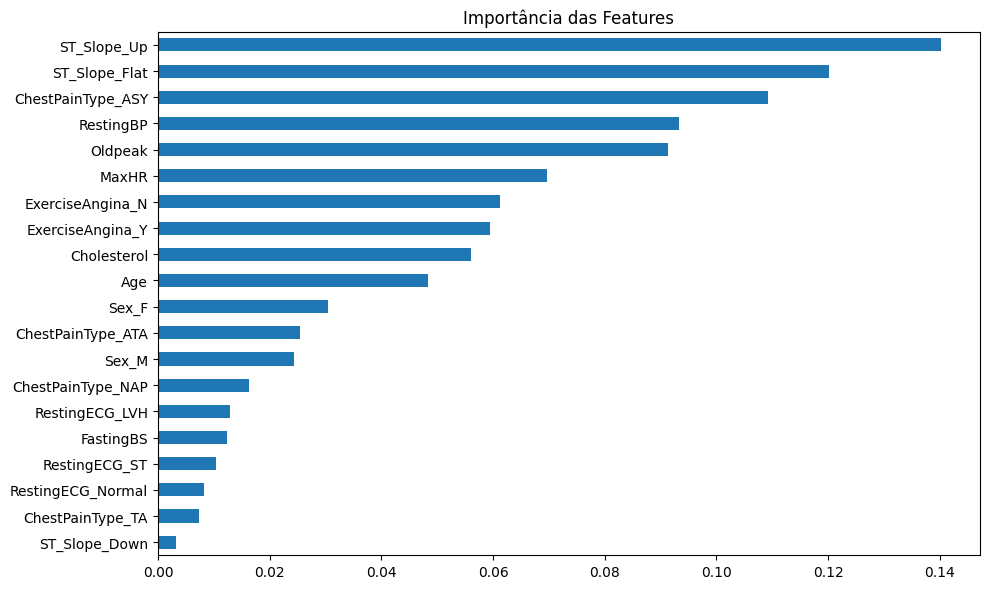

In [106]:
if hasattr(best_model, "calibrated_classifiers_"):
    pipeline = best_model.calibrated_classifiers_[0].estimator
else:
    pipeline = best_model

model = pipeline.named_steps["model"]

feature_names = (
    colunas_numericas +
    list(
        pipeline.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(colunas_categoricas)
    )
)

if hasattr(model, "feature_importances_"):
    importancias = model.feature_importances_
elif hasattr(model, "coef_"):
    importancias = model.coef_[0]
else:
    raise ValueError("Modelo não suporta feature importance")

os.makedirs("img", exist_ok=True)
pd.Series(importancias, index=feature_names)\
    .sort_values()\
    .plot(kind="barh", figsize=(10, 6))

plt.title("Importância das Features")
plt.tight_layout()
plt.savefig("img/feature_importance.png")
plt.show()

In [107]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_test).ravel()
print("\n── Resultado Final (Test Set) ──")
print(f"  Recall (Sensitivity): {tp / (tp + fn):.4f}")
print(f"  Specificity:          {tn / (tn + fp):.4f}")
print(f"  Precision:            {precision_score(y_test, y_pred_test):.4f}")
print(f"  F1:                   {f1_score(y_test, y_pred_test):.4f}")
print(f"\n{classification_report(y_test, y_pred_test)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_test)}")


── Resultado Final (Test Set) ──
  Recall (Sensitivity): 0.9118
  Specificity:          0.8659
  Precision:            0.8942
  F1:                   0.9029

              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

Confusion Matrix:
[[71 11]
 [ 9 93]]


In [108]:
os.makedirs("models", exist_ok=True) 

joblib.dump({
    "model": best_model,
    "threshold": best_t
}, 'models/modelo_cardiaco.pkl')

['models/modelo_cardiaco.pkl']